In [ ]:
# test correlated sampling method
# track the divergence of the walkers
# compare system with different electrons

In [75]:
from pyscf import gto, scf, cc

a = 1.20577 # bond length in a cluster
d = 4 # distance between each cluster
unit = 'A' # unit of length
na = 2 # size of a cluster (monomer)
nc = 1 # set as integer multiple of monomers
spin = 2 # spin per monomer
elmt = 'O'
basis = 'sto6g'
atoms = ""
for n in range(nc*na):
    shift = ((n - n % na) // na) * (d-a)
    atoms += f"{elmt} {n*a+shift:.5f} 0.00000 0.00000 \n"
###########################

mol1 = gto.M(atom=atoms,
            basis=basis,
            verbose=4,
            unit=unit,
            symmetry=0,
            charge=0,
            spin=spin*nc,
            max_memory=20000,
            )

mf1 = scf.UHF(mol1).density_fit()
mf1.kernel()

stable = False
while not stable:
    print(f'mean-field stability test')
    if not stable:
        mo_i, _, stable,_ = mf1.stability(return_status=True)
        dm = mf1.make_rdm1(mo_i,mf1.mo_occ)
        mf1.kernel(dm0=dm)
    elif stable:
        print(f'HF Energy: {mf1.e_tot}, stability {stable}')
        break

System: uname_result(system='Linux', node='sharmagroup-rn', release='6.17.0-35-generic', version='#35~24.04.1-Ubuntu SMP PREEMPT_DYNAMIC Tue May 26 19:30:42 UTC 2', machine='x86_64')  Threads 16
Python 3.12.13 | packaged by Anaconda, Inc. | (main, Mar 19 2026, 20:20:58) [GCC 14.3.0]
numpy 2.4.4  scipy 1.17.1  h5py 3.16.0
Date: Fri Jul 10 21:02:05 2026
PySCF version 2.12.1
PySCF path  /home/sharmagroup/sharmagroup/pyscf
GIT ORIG_HEAD 3d1768f5e33b144b606c3d2c81c12ee54d794501
GIT HEAD (branch master) f0861da51f017364d8bbaa20b742a94f3733305f

[ENV] OLD_PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge:
[ENV] PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge:/home/sharmagroup/sharmagroup/pyscf-forge:
[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 2
[INPUT] num. electrons = 16
[INPUT] charge = 0
[INPUT] spin (= nelec alpha-beta = 2S) = 2
[INPUT] symmetry 0 subgroup None
[INPUT] Mole.unit = A
[INPUT] Symbol           X                Y                Z      uni

In [76]:
import numpy as np

def make_singlet_occ(mo_occ):
    mo_occ = np.asarray(mo_occ)
    nelec = int(round(mo_occ.sum()))
    if nelec % 2 != 0:
        raise ValueError(f"Total electron count ({nelec}) is odd; "
                         "no closed-shell singlet possible.")
    nocc = nelec // 2                    # electrons per spin
    new_occ = np.zeros_like(mo_occ)
    new_occ[0, :nocc] = 1.0              # alpha
    new_occ[1, :nocc] = 1.0              # beta
    return new_occ

mo_occ_singlet = make_singlet_occ(mf1.mo_occ)
print(mo_occ_singlet)

[[1. 1. 1. 1. 1. 1. 1. 1. 0. 0.]
 [1. 1. 1. 1. 1. 1. 1. 1. 0. 0.]]


In [79]:
mol2 = gto.M(atom=atoms,
            basis=basis,
            verbose=4,
            unit=unit,
            symmetry=0,
            charge=0,
            spin=0*nc,
            max_memory=20000,
            )

mf2 = scf.UHF(mol2).density_fit()
# mf2.max_cycle = -1
dm0 = mf1.make_rdm1(mo_coeff=mf1.mo_coeff, mo_occ=mo_occ_singlet)
mf2.kernel()

stable = False
while not stable:
    print(f'mean-field stability test')
    if not stable:
        mo_i, _, stable,_ = mf2.stability(return_status=True)
        dm = mf2.make_rdm1(mo_i,mf2.mo_occ)
        mf2.kernel(dm0=dm)
    elif stable:
        print(f'HF Energy: {mf2.e_tot}, stability {stable}')
        break

System: uname_result(system='Linux', node='sharmagroup-rn', release='6.17.0-35-generic', version='#35~24.04.1-Ubuntu SMP PREEMPT_DYNAMIC Tue May 26 19:30:42 UTC 2', machine='x86_64')  Threads 16
Python 3.12.13 | packaged by Anaconda, Inc. | (main, Mar 19 2026, 20:20:58) [GCC 14.3.0]
numpy 2.4.4  scipy 1.17.1  h5py 3.16.0
Date: Fri Jul 10 21:02:21 2026
PySCF version 2.12.1
PySCF path  /home/sharmagroup/sharmagroup/pyscf
GIT ORIG_HEAD 3d1768f5e33b144b606c3d2c81c12ee54d794501
GIT HEAD (branch master) f0861da51f017364d8bbaa20b742a94f3733305f

[ENV] OLD_PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge:
[ENV] PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge:/home/sharmagroup/sharmagroup/pyscf-forge:
[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 2
[INPUT] num. electrons = 16
[INPUT] charge = 0
[INPUT] spin (= nelec alpha-beta = 2S) = 0
[INPUT] symmetry 0 subgroup None
[INPUT] Mole.unit = A
[INPUT] Symbol           X                Y                Z      uni

In [ ]:
from afqmc.corr_sample import integral as csi

def align_mo(mo1, mo2, nocc1, nocc2, frozen1, frozen2):
    
    assert mo1.shape == mo2.shape
    norb = mo1.shape[1]          # was shape[0] -- that's nao, not nmo

    if frozen1 is None:
        frzidx1 = []
    elif isinstance(frozen1, (int, np.integer)):
        frzidx1 = list(range(int(frozen1)))
    else:
        frzidx1 = sorted(int(i) % norb for i in frozen1)

    if frozen2 is None:
        frzidx2 = []
    elif isinstance(frozen2, (int, np.integer)):
        frzidx2 = list(range(int(frozen2)))
    else:
        frzidx2 = sorted(int(i) % norb for i in frozen2)

    # the index-padding trick below only makes sense if one frozen space
    # sits inside the other
    assert set(frzidx1) <= set(frzidx2) or set(frzidx2) <= set(frzidx1)
    
    actidx1 = [i for i in range(norb) if i not in frzidx1]
    actidx2 = [i for i in range(norb) if i not in frzidx2]

    frzoccidx1 = [i for i in frzidx1 if i in range(nocc1)]
    actoccidx1 = [i for i in actidx1 if i in range(nocc1)]
    actviridx1 = [i for i in actidx1 if i not in range(nocc1)]
    frzviridx1 = [i for i in frzidx1 if i not in range(nocc1)]

    frzoccidx2 = [i for i in frzidx2 if i in range(nocc2)]
    actoccidx2 = [i for i in actidx2 if i in range(nocc2)]
    actviridx2 = [i for i in actidx2 if i not in range(nocc2)]
    frzviridx2 = [i for i in frzidx2 if i not in range(nocc2)]

    nactocc1, nactocc2 = len(actoccidx1), len(actoccidx2)
    nactvir1, nactvir2 = len(actviridx1), len(actviridx2)

    # mo1_frzocc = mo1[:,frzoccidx1]
    # mo1_actocc = mo1[:,actoccidx1]
    # mo1_actvir = mo1[:,actviridx1]
    # mo1_frzvir = mo1[:,frzviridx1]

    # mo2_frzocc = mo2[:,frzoccidx2]
    # mo2_actocc = mo2[:,actoccidx2]
    # mo2_actvir = mo2[:,actviridx2]
    # mo2_frzvir = mo2[:,frzviridx2]


    mo1 = mo1.copy()   # we now assign columns in place; don't clobber the caller
    mo2 = mo2.copy()

    for it in range(20):
        mo1_prev, mo2_prev = mo1.copy(), mo2.copy()

        # occ
        if nactocc1 >= nactocc2:
            o = csi.right_procrustes(mo2[:, actoccidx1], mo1[:, actoccidx1])
            mo1[:, actoccidx1] = mo1[:, actoccidx1] @ o
        else:
            o = csi.right_procrustes(mo1[:, actoccidx2], mo2[:, actoccidx2])
            mo2[:, actoccidx2] = mo2[:, actoccidx2] @ o

        # vir, using the occ-aligned MOs
        if nactvir1 >= nactvir2:
            o = csi.right_procrustes(mo2[:, actviridx1], mo1[:, actviridx1])
            mo1[:, actviridx1] = mo1[:, actviridx1] @ o
        else:
            o = csi.right_procrustes(mo1[:, actviridx2], mo2[:, actviridx2])
            mo2[:, actviridx2] = mo2[:, actviridx2] @ o

        if nocc1 == nocc2:
            break   # blocks are decoupled; one pass is already exact
        if (abs(mo1 - mo1_prev).max() < 1e-10 and
            abs(mo2 - mo2_prev).max() < 1e-10):
            break
    else:
        print('align_mo did not converge')

    return mo1, mo2
    # # match the larger active vir with the smaller active occ with some occ
    # if nactvir1 >= nactvir2:
    #     o = csi.right_procrustes(mo2[:,actviridx1], mo1_actvir)
    #     mo1_actvir = mo1_actvir @ o
    # else:
    #     o = csi.right_procrustes(mo1[:,actviridx2], mo2_actvir)
    #     mo2_actvir = mo2_actvir @ o

    # mo1 = np.hstack([mo1_frzocc, mo1_actocc, mo1_actvir, mo1_frzvir])
    # mo2 = np.hstack([mo2_frzocc, mo2_actocc, mo2_actvir, mo2_frzvir])

    # # match the larger active occ with the smaller active occ with some vir
    # if nactocc1 >= nactocc2:
    #     o = csi.right_procrustes(mo2[:,actoccidx1], mo1_actocc)
    #     mo1_actocc = mo1_actocc @ o
    # else:
    #     o = csi.right_procrustes(mo1[:,actoccidx2], mo2_actocc)
    #     mo2_actocc = mo2_actocc @ o

    # mo1 = np.hstack([mo1_frzocc, mo1_actocc, mo1_actvir, mo1_frzvir])
    # mo2 = np.hstack([mo2_frzocc, mo2_actocc, mo2_actvir, mo2_frzvir])

    # return mo1, mo2


In [ ]:
# def align_mo(mo1, mo2, nocc1, nocc2, frozen1, frozen2):

#     assert mo1.shape == mo2.shape
#     norb = mo1.shape[1]          # was shape[0] -- that's nao, not nmo

#     if frozen1 is None:
#         frzidx1 = []
#     elif isinstance(frozen1, (int, np.integer)):
#         frzidx1 = list(range(int(frozen1)))
#     else:
#         frzidx1 = sorted(int(i) % norb for i in frozen1)

#     if frozen2 is None:
#         frzidx2 = []
#     elif isinstance(frozen2, (int, np.integer)):
#         frzidx2 = list(range(int(frozen2)))
#     else:
#         frzidx2 = sorted(int(i) % norb for i in frozen2)

#     # the index-padding trick below only makes sense if one frozen space
#     # sits inside the other
#     assert set(frzidx1) <= set(frzidx2) or set(frzidx2) <= set(frzidx1)

#     actidx1 = [i for i in range(norb) if i not in frzidx1]
#     actidx2 = [i for i in range(norb) if i not in frzidx2]

#     actoccidx1 = [i for i in actidx1 if i in range(nocc1)]
#     actviridx1 = [i for i in actidx1 if i not in range(nocc1)]

#     actoccidx2 = [i for i in actidx2 if i in range(nocc2)]
#     actviridx2 = [i for i in actidx2 if i not in range(nocc2)]

#     nactocc1, nactocc2 = len(actoccidx1), len(actoccidx2)
#     nactvir1, nactvir2 = len(actviridx1), len(actviridx2)

#     mo1 = mo1.copy()
#     mo2 = mo2.copy()

#     # same on the virtual side
#     if nactvir1 >= nactvir2:
#         assert all(i >= nocc2 for i in actviridx1)   # padding must stay virtual in mo2
#         o = csi.right_procrustes(mo2[:, actviridx1], mo1[:, actviridx1])
#         mo1[:, actviridx1] = mo1[:, actviridx1] @ o
#     else:
#         assert all(i >= nocc1 for i in actviridx2)
#         o = csi.right_procrustes(mo1[:, actviridx2], mo2[:, actviridx2])
#         mo2[:, actviridx2] = mo2[:, actviridx2] @ o

#     # match the larger active occ against the smaller-active-space MOs
#     # taken at the LARGER set's active occ indices
#     if nactocc1 >= nactocc2:
#         o = csi.right_procrustes(mo2[:, actoccidx1], mo1[:, actoccidx1])
#         mo1[:, actoccidx1] = mo1[:, actoccidx1] @ o
#     else:
#         o = csi.right_procrustes(mo1[:, actoccidx2], mo2[:, actoccidx2])
#         mo2[:, actoccidx2] = mo2[:, actoccidx2] @ o

#     return mo1, mo2

In [81]:
from pyscf.data import elements

frozen = elements.chemcore(mol1)
mo1a, mo1b = mf1.mo_coeff[0], mf1.mo_coeff[1]
mo2a, mo2b = mf2.mo_coeff[0], mf2.mo_coeff[1]
mo1 = (mo1a, mo1b)
mo2 = (mo2a, mo2b)
print(np.linalg.norm(mo1a[:,frozen:]-mo2a[:,frozen:]))
print(np.linalg.norm(mo1b[:,frozen:]-mo2b[:,frozen:]))

nocc1a = np.count_nonzero(mf1.mo_occ[0])
nocc1b = np.count_nonzero(mf1.mo_occ[1])
nocc2a = np.count_nonzero(mf2.mo_occ[0])
nocc2b = np.count_nonzero(mf2.mo_occ[1])

print(nocc1a, nocc1b)
print(nocc2a, nocc2b)

2.8988989526272952
2.9110593552209765
9 7
8 8


In [82]:
mo1a_new, mo2a_new = align_mo(mo1a, mo2a, nocc1a, nocc2a, frozen1=2, frozen2=2)
print(np.linalg.norm(mo1a[:,frozen:] - mo2a[:,frozen:]))
print(np.linalg.norm(mo1a_new[:,frozen:] - mo2a_new[:,frozen:]))

mo1b_new, mo2b_new = align_mo(mo1b, mo2b, nocc1b, nocc2b, frozen1=2, frozen2=2)
print(np.linalg.norm(mo1b[:,frozen:] - mo2b[:,frozen:]))
print(np.linalg.norm(mo1b_new[:,frozen:] - mo2b_new[:,frozen:]))

2.8988989526272952
0.07658718138759187
2.9110593552209765
0.33434191203956815


In [83]:
mf1.mo_coeff = (mo1a_new, mo1b_new)
mf2.mo_coeff = (mo2a_new, mo2b_new)

In [84]:
from afqmc.corr_sample import integral as csi
from pyscf.data import elements
csi.prep_integral(mf1, mf2, norb_frozen1=elements.chemcore(mol1), norb_frozen2=elements.chemcore(mol2))


Preparing AFQMC calculation
Calculating Cholesky integrals
Find Density Fit Teonsers in MF object
Integrals will be built by DF Tensors
Building JK matrix
Alpha Cholesky shape: (39, 8, 8) 
 Beta Cholesky shape: (39, 8, 8) 
Calculating Cholesky integrals
Find Density Fit Teonsers in MF object
Integrals will be built by DF Tensors
Building JK matrix
Alpha Cholesky shape: (39, 8, 8) 
 Beta Cholesky shape: (39, 8, 8) 
Original number of Cholesky: 39 vs 39
before   ||d||_F=4.117040e-01  overlap=0.995717
after    ||d||_F=4.096400e-01  overlap=0.995759
Finished calculating Cholesky integrals
Active Space:             System 1    System 2
Number of electrons:         [7 5]       [6 6]
Number of basis:                 8           8
Number of Cholesky:             39          39


In [85]:
options =  {'eql_time': 50,
            'n_prop_step': 30,
            'n_blocks': 20,
            'n_walkers': 500,
            'nchol_chunk': 30,
            'max_memory': 3000,
            'seed': 17,
            'trial': 'uhf',
            'mix_precision': False,
            }

In [86]:
import time
import numpy as np
from jax import numpy as jnp

from afqmc import config
from afqmc.corr_sample import prep
from afqmc.corr_sample import sampling as csp
from afqmc import sampling as sp

from functools import partial
print = partial(print, flush=True)

init_time = time.time()

prep.print_start()
config.setup_jax()

(prop, sampler, options, 
 trial1, ham_data1, wave_data1, 
 trial2, ham_data2, wave_data2) = prep.init_afqmc(options=options)

wave_data1["rdm1"] = trial1.get_rdm1(wave_data1)
wave_data2["rdm1"] = trial2.get_rdm1(wave_data2)

ham_data1 = trial1._build_measurement_intermediates(ham_data1, wave_data1)
ham_data2 = trial2._build_measurement_intermediates(ham_data2, wave_data2)

ham_data1 = prop._build_propagation_intermediates(ham_data1, trial1, wave_data1)
ham_data2 = prop._build_propagation_intermediates(ham_data2, trial2, wave_data2)

prop_data1 = prep.init_hf_prop_data(trial1, wave_data1, ham_data1, options)
prop_data2 = prep.init_hf_prop_data(trial2, wave_data2, ham_data2, options)

options["eql_time"] = 100

eql_prop_steps = 50
block_time = prop.dt * eql_prop_steps
neql_block = int(-(-options["eql_time"] // block_time))

sampler_eq = csp.sampler(
    n_prop_steps = 50,
    n_blocks = neql_block,
    n_walkers = sampler.n_walkers,
    n_chol = sampler.n_chol,
    )


    ________                     _____                    
    ___  __ \___  __________________(_)_____________ _    
    __  /_/ /  / / /_  __ \_  __ \_  /__  __ \_  __ `/    
    _  _, _// /_/ /_  / / /  / / /  / _  / / /  /_/ /     
    /_/ |_| \__,_/ /_/ /_//_/ /_//_/  /_/ /_/_\__, /      
                                             /____/       
    _____________________________  ___________            
    ___    |__  ____/_  __ \__   |/  /_  ____/            
    __  /| |_  /_   _  / / /_  /|_/ /_  /                 
    _  ___ |  __/   / /_/ /_  /  / / / /___               
    /_/  |_/_/      \___\_\/_/  /_/  \____/               

Hostname:     sharmagroup-rn
System:       Linux
Node:         sharmagroup-rn
Release:      6.17.0-35-generic
Machine:      x86_64
Processor:    x86_64
JAX backend:  GPU
JAX devices:  [CudaDevice(id=0)]
Device kind:  NVIDIA GeForce RTX 5060 Ti
Platform:     gpu

QMC Parameters
eql_time        -         50
n_prop_step     -         30
n_blocks     

In [87]:
from jax import jit
from afqmc.corr_sample import sr as csr

@partial(jit, static_argnums=(0, 1 ,2, 6))
def block_sample(self, prop,
                    trial1, prop_data1, ham_data1, wave_data1,
                    trial2, prop_data2, ham_data2, wave_data2,
                    ):
    """Block scan function. Propagation and energy calculation."""
    prop_data1, prop_data2 = self.prop_step(
        prop, 
        trial1, prop_data1, ham_data1, wave_data1,
        trial2, prop_data2, ham_data2, wave_data2
        )

    en_sp1 = jnp.real(trial1.calc_energy(prop_data1["walkers"], ham_data1, wave_data1))
    en_sp2 = jnp.real(trial2.calc_energy(prop_data2["walkers"], ham_data2, wave_data2))

    # rm extreme outliers
    outlier1 = jnp.abs(en_sp1 - prop_data1["e_estimate"]) > jnp.sqrt(2.0 / prop.dt)
    outlier2 = jnp.abs(en_sp2 - prop_data2["e_estimate"]) > jnp.sqrt(2.0 / prop.dt)
    outlier = outlier1 | outlier2 # union
    prop_data1["weights"] = jnp.where(outlier, 0.0, prop_data1["weights"])
    prop_data2["weights"] = jnp.where(outlier, 0.0, prop_data2["weights"])

    wt_sp1 = prop_data1["weights"]
    wt_sp2 = prop_data2["weights"]

    wt1 = jnp.sum(wt_sp1)
    wt2 = jnp.sum(wt_sp2)
    en1 = jnp.sum(wt_sp1 * en_sp1) / wt1
    en2 = jnp.sum(wt_sp2 * en_sp2) / wt2

    prop_data1, prop_data2 = csr.stochastic_reconfiguration(prop_data1, prop_data2)
    prop_data1["overlaps"] = trial1.calc_overlap(prop_data1["walkers"], wave_data1)
    prop_data2["overlaps"] = trial2.calc_overlap(prop_data2["walkers"], wave_data2)
    prop_data1["e_estimate"] = 0.9 * prop_data1["e_estimate"] + 0.1 * en1
    prop_data2["e_estimate"] = 0.9 * prop_data2["e_estimate"] + 0.1 * en2
    prop_data1["pop_control_ene_shift"] = prop_data1["e_estimate"]
    prop_data2["pop_control_ene_shift"] = prop_data2["e_estimate"]

    return (prop_data1, prop_data2), (wt1, en1, wt2, en2)

In [88]:
print("\nEquilibration")

print(
    f"{'1/T':>5s}  "
    f"{'weight1':>10s}  {'Energy1':>12s}  "
    f"{'weight2':>10s}  {'Energy2':>12s}  "
    f"{'dE12':>10s}  {'runTime':>8s}"
    )

print(
    f"{0.:5.2f}  "
    f"{jnp.sum(prop_data1["weights"]):10.5f}  {prop_data1["e_estimate"]:12.5f}  "
    f"{jnp.sum(prop_data2["weights"]):10.5f}  {prop_data2["e_estimate"]:12.5f}  "
    f"{prop_data1["e_estimate"]-prop_data2["e_estimate"]:10.5f}  {time.time() - init_time:8.2f}"
    )

wt1_sp = np.zeros(neql_block)
wt2_sp = np.zeros(neql_block)
en1_sp = np.zeros(neql_block)
en2_sp = np.zeros(neql_block)

for n in range(neql_block):
    (prop_data1, prop_data2), (wt1, en1, wt2, en2) \
        = block_sample(sampler_eq, prop, 
                                  trial1, prop_data1, ham_data1, wave_data1,
                                  trial2, prop_data2, ham_data2, wave_data2)
    
    wt1_sp[n] = wt1
    wt2_sp[n] = wt2
    en1_sp[n] = en1
    en2_sp[n] = en2
    prop_data1["e_estimate"] = 0.9 * prop_data1["e_estimate"] + 0.1 * en1
    prop_data2["e_estimate"] = 0.9 * prop_data2["e_estimate"] + 0.1 * en2

    if (n+1) % (min(max(neql_block // 10, 1), 20)) == 0 and n > 0:
        print(
            f"{(n+1)*block_time:5.2f}  "
            f"{wt1:10.5f}  {en1:12.5f}  "
            f"{wt2:10.5f}  {en2:12.5f}  "
            f"{en1-en2:10.5f}  {time.time()-init_time:8.2f}"
            )


Equilibration
  1/T     weight1       Energy1     weight2       Energy2        dE12   runTime
 0.00   500.00000    -149.05084   500.00000    -149.00152    -0.04932      2.77
 5.00   499.37758    -149.12901   498.85442    -149.07456    -0.05445      9.66
10.00   499.30312    -149.13280   498.28158    -149.09571    -0.03708     11.67
15.00   499.27378    -149.16349   497.80236    -149.13001    -0.03348     13.67
20.00   498.51350    -149.12370   497.45598    -149.10395    -0.01975     15.68
25.00   499.97764    -149.17317   497.19211    -149.10721    -0.06596     17.68
30.00   498.98719    -149.13025   496.64272    -149.11315    -0.01710     19.68
35.00   499.70674    -149.15249   497.70886    -149.11213    -0.04036     21.69
40.00   498.90040    -149.12858   497.14574    -149.09498    -0.03360     23.69
45.00   499.81857    -149.15650   497.40561    -149.11473    -0.04176     25.70
50.00   499.61553    -149.16318   498.30494    -149.12060    -0.04258     27.70
55.00   499.07708    -149

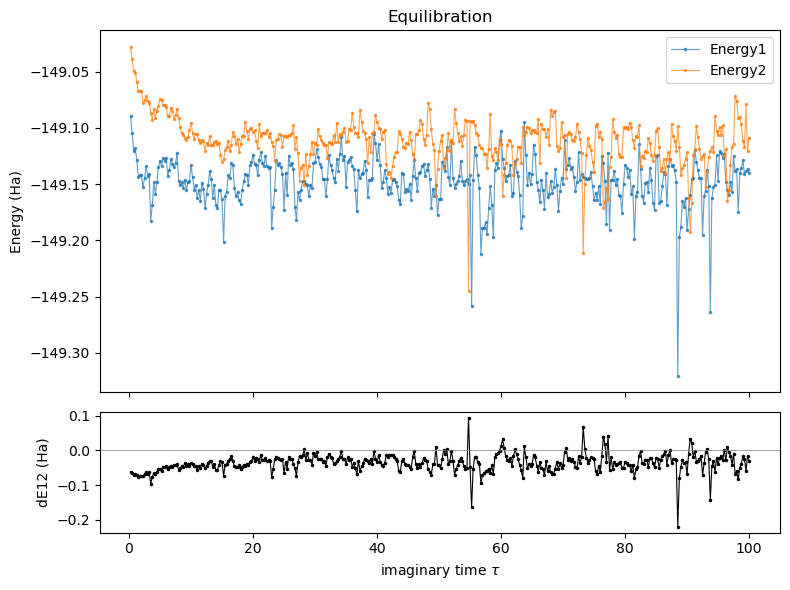

In [89]:
import matplotlib.pyplot as plt

t = (np.arange(neql_block) + 1) * block_time

fig, (ax, axd) = plt.subplots(
    2, 1, sharex=True, figsize=(8, 6),
    gridspec_kw={"height_ratios": [3, 1]},
)

ax.plot(t, en1_sp, ".-", lw=0.8, ms=3, alpha=0.7, label="Energy1")
ax.plot(t, en2_sp, ".-", lw=0.8, ms=3, alpha=0.7, label="Energy2")
ax.set_ylabel("Energy (Ha)")
ax.legend()
ax.set_title("Equilibration")

# difference -- usually the quantity you actually care about
axd.plot(t, en1_sp - en2_sp, ".-", lw=0.8, ms=3, color="k")
axd.axhline(0.0, color="grey", lw=0.5)
axd.set_ylabel("dE12 (Ha)")
axd.set_xlabel(r"imaginary time $\tau$")

fig.tight_layout()
fig.savefig("eql_energy.png", dpi=150)
plt.show()

In [90]:
teql = 20.0                       # equilibration time, au
neq  = int(np.ceil(teql / block_time))
sl   = slice(neq, None)

e1, e2 = en1_sp[sl], en2_sp[sl]
de     = e1 - e2
n      = len(de)
print(f"\nAnalysis: discarding {neq} blocks (tau < {teql:g}), keeping {n}")


def reblock(x):
    """Error on the mean vs bin size. Returns (sizes, errs, n_bins)."""
    sizes, errs, nbins = [], [], []
    b = 1
    while len(x) // b >= 8:                      # need enough bins to trust sigma
        nb = len(x) // b
        m  = x[: nb * b].reshape(nb, b).mean(axis=1)
        sizes.append(b)
        errs.append(m.std(ddof=1) / np.sqrt(nb))
        nbins.append(nb)
        b *= 2
    return np.array(sizes), np.array(errs), np.array(nbins)


def analyze(x, label):
    sizes, errs, nbins = reblock(x)
    i   = int(np.argmax(errs))                   # plateau ~ largest stable estimate
    err = errs[i]
    tau = 0.5 * (err / errs[0]) ** 2             # integrated autocorr time, in blocks
    print(f"  {label:>6s} = {x.mean():12.6f} +/- {err:9.6f}   "
          f"(bin {sizes[i]:3d}, {nbins[i]:3d} bins, tau_int {tau:5.1f})")
    return x.mean(), err, sizes, errs


print(f"  {'':>6s}   {'mean':>12s}     {'err':>9s}")
m1, s1, sz1, er1 = analyze(e1, "E1")
m2, s2, sz2, er2 = analyze(e2, "E2")
md, sd, szd, erd = analyze(de, "dE12")

naive = np.sqrt(s1**2 + s2**2)
print(f"\n  dE12 = {md:.6f} +/- {sd:.6f}   "
      f"(uncorrelated estimate would be +/- {naive:.6f}, "
      f"gain {naive / sd:.1f}x)")
print(f"  corr(E1, E2) = {np.corrcoef(e1, e2)[0, 1]:+.3f}")


Analysis: discarding 80 blocks (tau < 20), keeping 320
                   mean           err
      E1 =  -149.147426 +/-  0.001956   (bin   8,  40 bins, tau_int   1.2)
      E2 =  -149.114775 +/-  0.001674   (bin  16,  20 bins, tau_int   1.2)
    dE12 =    -0.032651 +/-  0.002052   (bin   8,  40 bins, tau_int   0.9)

  dE12 = -0.032651 +/- 0.002052   (uncorrelated estimate would be +/- 0.002574, gain 1.3x)
  corr(E1, E2) = +0.167
